# Transformers

## Topic
From Transformer Basics to Encoder Self-Attention, Multi-Head Attention, and Decoder Blocks


### Part 1 — Motivation and Big Picture
- Why RNNs/LSTMs are limited
- Why attention changed sequence modeling
- High-level Transformer architecture

### Part 2 — Self-Attention Fundamentals
- Query, Key, Value
- Scaled dot-product attention
- Why scaling is needed

### Part 3 — Encoder and Contextual Embeddings
- Static vs contextual embeddings
- Encoder workflow
- Positional encoding
- Residual connections and layer normalization

### Part 4 — Multi-Head Attention
- Why one head is not enough
- Multiple learned projections
- Shape interpretation

### Part 5 — Decoder Block
- Masked self-attention
- Cross-attention
- Autoregressive generation

### Part 6 — Summary and In-Class Exercises
- Concept check
- Coding prompts


## Learning Objectives

By the end of this lecture, students will be able to:

- Explain why Transformers were introduced
- Describe the encoder-decoder structure of the Transformer
- Explain self-attention using Query, Key, and Value
- Compute scaled dot-product attention
- Explain contextual word embeddings in Transformer encoders
- Describe multi-head attention and why it is useful
- Explain masked attention and cross-attention in the decoder
- Interpret basic PyTorch implementations of Transformer components


## 1. Why Do We Need Transformers?

Before Transformers, sequence learning relied heavily on:

- RNNs
- LSTMs
- GRUs

These models process one token at a time.

For example, for the sentence:

**"I love deep learning"**

an RNN processes:

- I
- then love
- then deep
- then learning

This sequential style creates limitations for long sequences and makes parallel training difficult.


## 2. Limitations of RNN-Based Models

### Sequential computation
RNNs are hard to parallelize because tokens are processed one after another.

### Long-range dependency problems
Important information from much earlier in the sequence can become hard to preserve.

Example:

**"The student who studied all night before the exam was exhausted."**

The model must connect **student** and **exhausted** across many words.

### Training bottlenecks
Even stronger recurrent models like LSTMs can still be slow and less effective on long sequences.


## 3. Main Idea of the Transformer

The Transformer removes recurrence and instead uses:

## Attention

Each token can directly look at other tokens in the sequence and decide which ones matter most.

This gives major advantages:

- better long-range dependency handling
- parallel computation
- faster large-scale training


## 4. High-Level Transformer Architecture

A standard Transformer has two major parts:

### Encoder
Reads the input sequence and builds contextual representations.

### Decoder
Uses those representations and previously generated outputs to generate the next output token.

Example:
- Input: **"I love AI"**
- Output: **"J'aime l'IA"**


## 5. Encoder and Decoder Structure

### Encoder layer
Each encoder layer contains:

1. Multi-Head Self-Attention
2. Add & Norm
3. Feed-Forward Network
4. Add & Norm

### Decoder layer
Each decoder layer contains:

1. Masked Multi-Head Self-Attention
2. Encoder-Decoder Cross-Attention
3. Feed-Forward Network
4. Add & Norm


<img src="https://deeprevision.github.io/posts/001-transformer/transformer.png" alt="Architecture diagram of the Transformer model, showing encoder and decoder blocks.">

## 6. Self-Attention: Query, Key, and Value

In the Transformer architecture, the **Self-Attention** mechanism allows the model to map dependencies between words regardless of their distance in the sequence. To do this, it transforms each input token into three distinct functional vectors.

### 🔹 The Intuition: The "Search Engine" Analogy

Think of the self-attention process like a database retrieval system:

* **Query ($Q$):** "What am I looking for?" (Representing the current word's search criteria).
* **Key ($K$):** "What kind of information do I offer?" (The label or index of a word).
* **Value ($V$):** "What actual information do I provide?" (The content of the word).



### 🔹 The Calculation
The model compares every **Query** with every **Key** to determine a relevance score. This score decides how much "attention" the current word should pay to every other word in the sentence.

The core formula for Scaled Dot-Product Attention is:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

---

### 🔹 Breaking Down the Formula:
1.  **$QK^T$ (Dot Product):** Measures the similarity between the Query of the current word and the Keys of all other words.
2.  **$\sqrt{d_k}$ (Scaling Factor):** We divide by the square root of the dimension of the keys. This prevents the dot products from growing too large, which would cause the gradients to vanish during Softmax.
3.  **Softmax:** Normalizes the scores into probabilities (attention weights) that sum to 1.
4.  **Multiplying by $V$:** We take a weighted sum of the Value vectors. The "Value" of words with higher relevance scores will contribute more to the final contextual representation of the current token.



> **Key Takeaway:** Instead of a static word vector, the output of this layer is a **contextualized** vector that knows about its neighbors.

## 7. Why the Scaling Term Is Needed

In the Scaled Dot-Product Attention formula, we divide the dot product of the Query and Key by the square root of the dimension of the keys:

$$\text{Score} = \frac{Q \cdot K^T}{\sqrt{d_k}}$$

### 🔹 The Problem: "Exploding" Dot Products
As the dimensionality ($d_k$) of the vectors increases, the magnitude of the dot product tends to grow. To understand why, imagine $Q$ and $K$ are independent random variables with mean $0$ and variance $1$. Their dot product, $Q \cdot K = \sum_{i=1}^{d_k} q_i k_i$, will have a mean of $0$ but a **variance of $d_k$**.

[Image of dot product variance growth with dimensionality]

### 🔹 The Softmax "Saturation" Effect
When the dot products become very large (either highly positive or highly negative), the **Softmax** function reaches a region where its gradient is extremely small (

In [1]:
import torch
import torch.nn.functional as F

Q = torch.tensor([[1., 0., 1.]])
K = torch.tensor([
    [1., 1., 0.],
    [0., 1., 1.],
    [1., 0., 1.]
])
V = torch.tensor([
    [10., 0.],
    [0., 20.],
    [5., 5.]
])

scores = torch.matmul(Q, K.T) / (K.size(-1) ** 0.5)
weights = F.softmax(scores, dim=-1)
output = torch.matmul(weights, V)

print("Scores:")
print(scores)
print("\nAttention Weights:")
print(weights)
print("\nAttention Output:")
print(output)


Scores:
tensor([[0.5774, 0.5774, 1.1547]])

Attention Weights:
tensor([[0.2645, 0.2645, 0.4711]])

Attention Output:
tensor([[5.0000, 7.6446]])


## 8. Interpreting Self-Attention

The attention weights tell us how much the current token focuses on each token in the sequence.

So the final output representation becomes a weighted combination of information from multiple positions.

That is why self-attention produces context-aware representations.


## 9. From Static to Contextual Embeddings

Traditional embeddings such as **Word2Vec** or **GloVe** assign one vector per word.

That means the word always gets the same representation.

Example:

**bank** can mean:
- a financial institution
- the side of a river

A static embedding gives the same vector in both cases.

Transformer encoders instead produce:

## Contextual embeddings

The representation of a word depends on the surrounding sentence.


## 10. Example: Same Word, Different Meaning

Consider these two sentences:

1. **I deposited money at the bank.**
2. **The boat stopped near the river bank.**

A Transformer encoder can produce different representations for **bank** in each sentence because self-attention uses surrounding words.


In [2]:
import torch
import torch.nn.functional as F

# "bank" in a finance context
bank_finance = torch.tensor([
    [1.5, 0.2, 0.1],   # deposited
    [1.2, 0.3, 0.0],   # money
    [1.0, 1.0, 1.0],   # bank
])

# "bank" in a river context
bank_river = torch.tensor([
    [0.1, 1.4, 0.2],   # river
    [0.2, 1.2, 0.3],   # boat/fisherman-like context
    [1.0, 1.0, 1.0],   # bank
])

def simple_attention(x):
    scores = torch.matmul(x, x.T) / (x.size(-1) ** 0.5)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, x)
    return output, weights

out_fin, w_fin = simple_attention(bank_finance)
out_riv, w_riv = simple_attention(bank_river)

print("Contextual representation of 'bank' in finance context:")
print(out_fin[-1])

print("\nContextual representation of 'bank' in river context:")
print(out_riv[-1])


Contextual representation of 'bank' in finance context:
tensor([1.1740, 0.6384, 0.5467])

Contextual representation of 'bank' in river context:
tensor([0.5872, 1.1457, 0.6358])


## 11. Positional Encoding

One of the most distinct characteristics of the Transformer is that it contains no recurrence (like RNNs) and no convolutions (like CNNs). While this allows for massive parallelization, it introduces a major problem: **The model is permutation-invariant.**

### 🔹 The Problem: "Bag of Words"
Because self-attention treats the input as a set of vectors, it does not inherently know the order of tokens. To the attention mechanism, these two sentences look identical:

1.  **Dog bites man**
2.  **Man bites dog**

Without a sense of position, the model cannot distinguish between the subject and the object in these sentences.

---

### 🔹 The Solution: Sinusoidal Positional Encodings
To give the model a sense of order, we add **Positional Encodings (PE)** to the input embeddings. These are vectors of the same dimension as the word embeddings ($d$), which "inject" information about the specific index of each word.

A common approach uses sine and cosine functions of different frequencies:



**The Formulas:**

For a position $pos$ and dimension index $2i$ (even):
$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$

For a position $pos$ and dimension index $2i+1$ (odd):
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

---

### 🔹 Why Use Sines and Cosines?
1.  **Fixed vs. Relative:** The authors hypothesized that this would allow the model to easily learn to attend by **relative positions**, since for any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$.
2.  **Generalization:** It allows the model to potentially extrapolate to sequence lengths longer than those encountered during training.
3.  **Unique Signatures:** Each position gets a unique "signature" that is added directly to the word embedding.



> **Key Takeaway:** Positional encoding is the "compass" that tells the Transformer where each word stands in the stream of time, turning a bag of words back into a structured sentence.

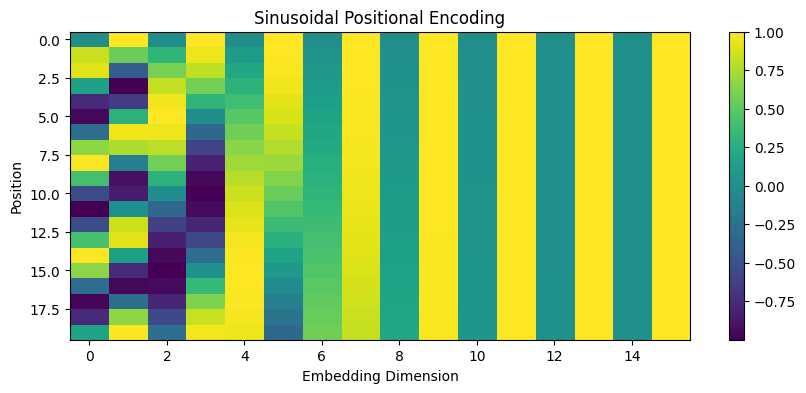

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    positions = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(positions * div_term)
    pe[:, 1::2] = np.cos(positions * div_term)
    return pe

pe = positional_encoding(20, 16)

plt.figure(figsize=(10, 4))
plt.imshow(pe, aspect='auto')
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")
plt.show()


## 12. Residual Connections, LayerNorm, and Feed-Forward Networks

While Self-Attention is the "brain" of the Transformer, these additional components act as the "nervous system" and "muscles," providing stability and processing power to each layer.

### 🔹 1. Position-wise Feed-Forward Network (FFN)
After the attention mechanism "mixes" information across tokens, the FFN processes each token independently. It consists of two linear transformations with a non-linear activation (typically **ReLU**) in between:

$$FFN(x) = \max(0, xW_1 + b_1)W_2 + b_2$$



* **Dimension Expansion:** Usually, the inner layer ($W_1$) expands the dimension (e.g., from 512 to 2048) and the second layer ($W_2$) contracts it back to the model dimension.

---

### 🔹 2. Residual Connections (Skip Connections)
To prevent the **Vanishing Gradient** problem in very deep networks, Transformers use residual connections around each sub-layer (Attention and FFN).

$$\text{Output} = x + \text{Sublayer}(x)$$



This allows the original input $x$ to "skip" the layer, providing a direct path for gradients to flow during backpropagation. It ensures that the layer learns a **modification** to the input rather than having to reconstruct the entire representation from scratch.

---

### 🔹 3. Layer Normalization (LayerNorm)
LayerNorm is applied to stabilize the hidden state dynamics and reduce training time. Unlike Batch Normalization, LayerNorm normalizes across the features of a single data point.

In a Transformer, this is typically combined with the residual connection in a pattern called **Add & Norm**:

$$\text{Layer Output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$



### 🔹 Summary of a Transformer Block
A single "Encoder Block" is composed of:
1. **Multi-Head Self-Attention** $\rightarrow$ Add & Norm
2. **Feed-Forward Network** $\rightarrow$ Add & Norm

> **Key Takeaway:** Residual connections and LayerNorm are the "stabilizers" that allow Transformers to be stacked dozens (or hundreds) of layers deep without the training process collapsing.

## 13. Why One Attention Head Is Not Enough

A single attention map may not capture all useful relationships in language.

A sentence can contain multiple patterns at once, such as:

- syntax
- semantic similarity
- long-distance reference
- subject-object relationship
- modifier relationship

This leads to:

## Multi-Head Attention


## 14. Multi-Head Attention

While self-attention is powerful, a single "head" might only focus on one specific type of relationship (e.g., the subject of a sentence). **Multi-Head Attention (MHA)** allows the model to jointly attend to information from different representation subspaces at different positions.

### 🔹 Step 1: Independent Projections
Instead of performing a single attention function, we project the Queries ($Q$), Keys ($K$), and Values ($V$) into $h$ different, lower-dimensional versions using learned weight matrices ($W_i^Q, W_i^K, W_i^V$):

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

Each of these "heads" can learn to focus on something different:
* **Head 1** might focus on grammar.
* **Head 2** might focus on semantic meaning.
* **Head 3** might focus on distant relationships.



---

### 🔹 Step 2: Concatenation and Final Projection
Once all $h$ heads have finished their parallel calculations, the model "stitches" them back together. To return the combined information to the original model dimension, we use a final learned projection matrix $W^O$:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$



---

### 🔹 Why This Matters
If you only had one head, you would effectively be averaging all possible word relationships into one value. Multi-head attention ensures that:
1. **Diverse Perspectives:** The model can capture coreference (who "he" refers to) and syntax (the verb of the sentence) simultaneously.
2. **Computational Efficiency:** By reducing the dimension of each head (e.g., $d_{model}/h$), the total cost of Multi-Head Attention is similar to that of full-dimensionality single-head attention.

> **Key Takeaway:** Multi-head attention is like having a team of experts looking at the same sentence, each pointing out a different important detail, and then combining their findings into one comprehensive summary.

## 15. Example Dimensions

Suppose:

- model dimension = 128
- number of heads = 8

Then each head may use:

- head dimension = 16

So attention is computed in multiple smaller subspaces and combined afterward.


In [4]:
d_model = 128
num_heads = 8
head_dim = d_model // num_heads

print("Model dimension:", d_model)
print("Number of heads:", num_heads)
print("Dimension per head:", head_dim)


Model dimension: 128
Number of heads: 8
Dimension per head: 16


In [5]:
import torch
import torch.nn as nn

mha = nn.MultiheadAttention(embed_dim=16, num_heads=4, batch_first=True)

x = torch.randn(2, 5, 16)   # (batch_size, seq_len, embed_dim)

output, attn_weights = mha(x, x, x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Attention weights shape:", attn_weights.shape)


Input shape: torch.Size([2, 5, 16])
Output shape: torch.Size([2, 5, 16])
Attention weights shape: torch.Size([2, 5, 5])


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        weights = F.softmax(scores, dim=-1)
        head_outputs = torch.matmul(weights, V)

        head_outputs = head_outputs.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.Wo(head_outputs)
        return output, weights

x = torch.randn(2, 6, 12)
model = SimpleMultiHeadAttention(d_model=12, num_heads=3)

output, weights = model(x)

print("Output shape:", output.shape)
print("Attention weights shape:", weights.shape)


Output shape: torch.Size([2, 6, 12])
Attention weights shape: torch.Size([2, 3, 6, 6])


## 16. Interpreting the Multi-Head Shapes

If attention weights have shape:

- `(batch_size, num_heads, seq_len, seq_len)`

that means:

- for each example
- for each head
- every token attends to every token

Each head gets its own attention map.


## 17. Decoder Block: Why It Is Different

The decoder block must generate output tokens step by step.

So it needs two kinds of attention:

1. **Masked self-attention**
2. **Cross-attention to encoder outputs**

That is why decoder blocks are slightly more complex than encoder blocks.


## 18. Masked Self-Attention

Inside the decoder:

- Queries come from decoder tokens
- Keys come from decoder tokens
- Values come from decoder tokens

So it is still self-attention.

But the mask prevents a token from seeing future tokens.


In [7]:
import torch

seq_len = 5
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1)
mask = mask.masked_fill(mask == 1, float('-inf'))

print("Causal mask:")
print(mask)


Causal mask:
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


In [8]:
import torch
import torch.nn.functional as F

scores = torch.tensor([
    [2.0, 1.0, 0.5, 0.3],
    [1.2, 2.2, 0.7, 0.1],
    [0.4, 1.1, 2.5, 0.9],
    [0.3, 0.8, 1.4, 2.0]
])

mask = torch.triu(torch.ones(4, 4), diagonal=1)
mask = mask.masked_fill(mask == 1, float('-inf'))

masked_scores = scores + mask
weights = F.softmax(masked_scores, dim=-1)

print("Original scores:")
print(scores)
print("\nMasked scores:")
print(masked_scores)
print("\nAttention weights after masking:")
print(weights)


Original scores:
tensor([[2.0000, 1.0000, 0.5000, 0.3000],
        [1.2000, 2.2000, 0.7000, 0.1000],
        [0.4000, 1.1000, 2.5000, 0.9000],
        [0.3000, 0.8000, 1.4000, 2.0000]])

Masked scores:
tensor([[2.0000,   -inf,   -inf,   -inf],
        [1.2000, 2.2000,   -inf,   -inf],
        [0.4000, 1.1000, 2.5000,   -inf],
        [0.3000, 0.8000, 1.4000, 2.0000]])

Attention weights after masking:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.2689, 0.7311, 0.0000, 0.0000],
        [0.0894, 0.1801, 0.7304, 0.0000],
        [0.0899, 0.1482, 0.2700, 0.4920]])


## 19. Cross-Attention in the Decoder

In cross-attention:

- **Queries** come from decoder hidden states
- **Keys** come from encoder outputs
- **Values** come from encoder outputs

This allows the decoder to look back at the input sequence while generating each output token.


In [9]:
import torch
import torch.nn.functional as F

# decoder states act as queries
Q = torch.randn(2, 4)   # 2 decoder positions, dim=4

# encoder outputs act as keys and values
K = torch.randn(5, 4)   # 5 source positions, dim=4
V = torch.randn(5, 6)   # 5 source positions, value dim=6

scores = torch.matmul(Q, K.T) / (K.size(-1) ** 0.5)
weights = F.softmax(scores, dim=-1)
output = torch.matmul(weights, V)

print("Cross-attention scores shape:", scores.shape)
print("Cross-attention weights shape:", weights.shape)
print("Cross-attention output shape:", output.shape)


Cross-attention scores shape: torch.Size([2, 5])
Cross-attention weights shape: torch.Size([2, 5])
Cross-attention output shape: torch.Size([2, 6])


## 20. Why the Decoder Is Autoregressive

The decoder generates tokens one step at a time:

- generate first token
- then use it to generate second
- then use first and second to generate third

That is why masking is necessary during training.

At step `t`, the model should only use tokens up to position `t`.


In [10]:
tokens = ["<start>", "I", "love", "AI"]

for i in range(1, len(tokens) + 1):
    context = tokens[:i]
    print(f"Step {i}: decoder can use -> {context}")


Step 1: decoder can use -> ['<start>']
Step 2: decoder can use -> ['<start>', 'I']
Step 3: decoder can use -> ['<start>', 'I', 'love']
Step 4: decoder can use -> ['<start>', 'I', 'love', 'AI']


## 21. Full Transformer in PyTorch

The following example uses PyTorch's built-in Transformer module.


In [11]:
import torch
import torch.nn as nn

model = nn.Transformer(
    d_model=128,
    nhead=8,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    batch_first=False
)

src = torch.rand(7, 3, 128)   # source length, batch size, d_model
tgt = torch.rand(5, 3, 128)   # target length, batch size, d_model

output = model(src, tgt)

print("Transformer output shape:", output.shape)


Transformer output shape: torch.Size([5, 3, 128])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


## 22. Transformer vs RNN/LSTM

| Feature | RNN/LSTM | Transformer |
|---|---|---|
| Processing style | Sequential | Parallel |
| Long-range dependency handling | Harder | Stronger |
| Main mechanism | Recurrence | Attention |
| Training speed | Slower | Faster on parallel hardware |
| Positional information | Built-in from order | Added explicitly |


## 23. Final Summary

This lecture combined five connected Transformer topics into one flow:

- motivation for Transformers
- self-attention
- contextual embeddings in the encoder
- multi-head attention
- decoder blocks with masking and cross-attention

Core ideas to remember:

- Transformers replace recurrence with attention
- encoder outputs are contextual embeddings
- multiple heads learn different relationships
- decoder masking prevents looking ahead
- cross-attention connects output generation to the input sequence
